# Regression Lab — Group B: Student Exam Score Prediction

| Key | Value |
|---|---|
| **Course** | BBT 4106 / BCM 3104 / BFS 4102 |
| **Group** | B |
| **Dataset** | `student_exam_score.csv` |
| **Target** | `final_exam_score` |
| **Members** | 148396 - Ida Aluso, 169884 - Derby Muchiri, Bridgette Juma, Brian Kioko, Charles Kabuga, 170160 - Kibiru Collins Kairuki |

**Educational context.** An academic advising platform and university department want a defensible estimate of a student's predicted **final exam score (0–100)** from their observable academic habits, attendance, and demographic background. Such a model can be used to (a) flag students at risk of underperforming early in the semester, and (b) help advisors recommend targeted interventions (such as tutoring or study groups) based on data-backed key drivers of student success.

This notebook follows a similar workflow to what was covered in class: EDA, train/test split, feature selection on training data only, preprocessing pipeline, cross-validated model comparison, diagnostics, test-set evaluation, hyperparameter tuning, explainability, and persistence.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import warnings
warnings.filterwarnings("ignore")

print("Environment ready.")

Environment ready.


## 2. Load the data

In [3]:
dataset_path = "student_exam_score.csv"

import os
# Support the repository layout locally and Colab uploads.
candidate_paths = [
    dataset_path,
    os.path.join("data", dataset_path),
    os.path.join(os.path.dirname(os.getcwd()), "data", dataset_path),
    f"/content/{dataset_path}",
]
csv_path = next((path for path in candidate_paths if os.path.exists(path)), None)

if csv_path is None:
    raise FileNotFoundError(
        "student_exam_score.csv not found. Expected it in the current folder, "
        "the repository data/ folder, or /content in Colab."
    )

exam_data = pd.read_csv(csv_path)

print(f"Loaded dataset from: {csv_path}")
print(f"Shape: {exam_data.shape[0]} rows, {exam_data.shape[1]} columns")
TARGET = "final_exam_score"

print(f"Target variable: {TARGET}")
print(f"Number of candidate predictors (excluding ID and target): {exam_data.shape[1] - 2}")
exam_data.head()


Loaded dataset from: data\student_exam_score.csv
Shape: 850 rows, 16 columns
Target variable: final_exam_score
Number of candidate predictors (excluding ID and target): 14


,student_id,major_subject,parental_education_level,internet_access_quality,part_time_job,study_group_participation,study_hours_per_week,attendance_rate_pct,previous_gpa,sleep_hours_per_night,extracurricular_activities_count,stress_level_score,tutoring_hours_per_week,distance_from_home_km,part_time_job_hours_per_week,final_exam_score
0,1,Sciences,Master's,Good,No,Yes,4.1,92.5,2.076569,6.3,2,6.0,1.1,5.1,NaN,73.0
1,2,Engineering,Master's,Good,No,No,8.8,100.0,1.922298,7.3,1,7.0,1.2,4.9,NaN,79.1
2,3,Humanities,High School,Good,Yes,No,7.0,80.5,2.308588,6.7,3,6.0,0.5,5.7,24.299416,73.9
3,4,Humanities,Doctorate,Average,No,Yes,5.4,83.8,2.448435,7.3,0,6.0,1.2,6.5,NaN,80.3
4,5,Business,Master's,Poor,No,No,11.6,78.4,2.218870,7.1,0,2.0,2.6,18.2,NaN,78.9


## 3. Exploratory Data Analysis

Numeric columns: ['study_hours_per_week', 'attendance_rate_pct', 'previous_gpa', 'sleep_hours_per_night', 'extracurricular_activities_count', 'stress_level_score', 'tutoring_hours_per_week', 'distance_from_home_km', 'part_time_job_hours_per_week', 'final_exam_score']
Categorical columns: ['major_subject', 'parental_education_level', 'internet_access_quality', 'part_time_job', 'study_group_participation']


,min,q1_25%,q2_50%,q3_75%,max,mean,std_dev,skewness,IQR
study_hours_per_week,0.10,4.20,6.85,10.30,38.20,7.92,5.09,1.44,6.10
attendance_rate_pct,45.70,72.03,82.20,91.57,100.00,81.29,12.97,-0.39,19.55
previous_gpa,1.46,2.56,2.93,3.28,4.00,2.91,0.53,-0.09,0.72
sleep_hours_per_night,3.00,5.80,6.60,7.30,10.00,6.60,1.17,0.04,1.50
extracurricular_activities_count,0.00,0.00,1.00,2.00,7.00,1.39,1.21,0.78,2.00
stress_level_score,1.00,4.00,6.00,7.00,10.00,5.48,2.03,-0.10,3.00
tutoring_hours_per_week,0.00,0.80,1.70,2.90,10.70,1.99,1.65,1.14,2.10
distance_from_home_km,0.30,4.60,7.60,11.80,40.80,8.92,6.12,1.42,7.20
part_time_job_hours_per_week,2.00,11.21,14.42,18.19,33.61,14.51,4.89,0.06,6.98
final_exam_score,18.70,78.90,85.70,92.60,100.00,85.26,9.89,-0.83,13.70


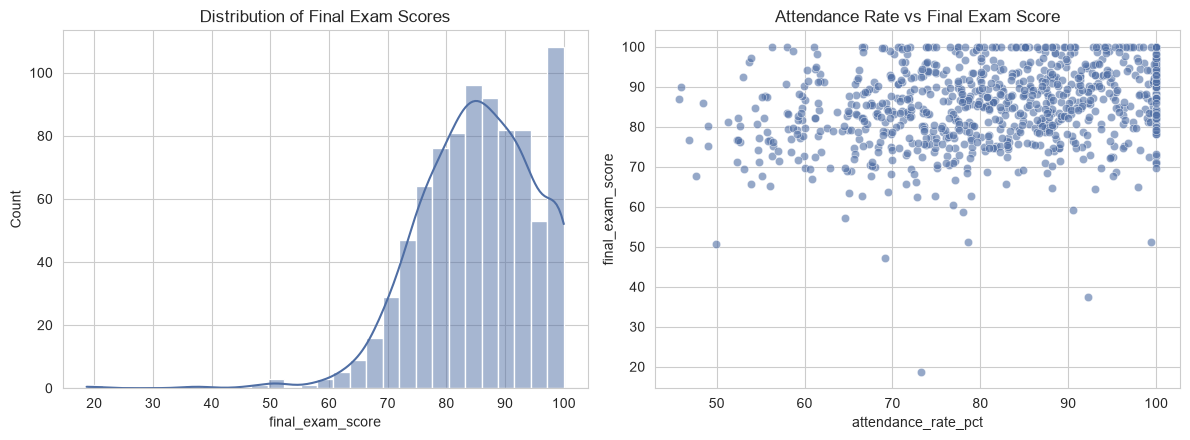

In [4]:
numeric_cols = exam_data.select_dtypes(include=[np.number]).columns.drop("student_id")
categorical_cols = exam_data.select_dtypes(exclude=[np.number]).columns

print("Numeric columns:", numeric_cols.tolist())
print("Categorical columns:", categorical_cols.tolist())

# Distribution summary
q1 = exam_data[numeric_cols].quantile(0.25)
q3 = exam_data[numeric_cols].quantile(0.75)
iqr = q3 - q1

distribution_summary = pd.DataFrame({
    "min": exam_data[numeric_cols].min(),
    "q1_25%": q1,
    "q2_50%": exam_data[numeric_cols].quantile(0.50),
    "q3_75%": q3,
    "max": exam_data[numeric_cols].max(),
    "mean": exam_data[numeric_cols].mean(),
    "std_dev": exam_data[numeric_cols].std(),
    "skewness": exam_data[numeric_cols].skew(),
    "IQR": iqr
})
display(distribution_summary.round(2))

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(exam_data[TARGET], kde=True, ax=axes[0], color="#4F6EA4")
axes[0].set_title("Distribution of Final Exam Scores")
sns.scatterplot(data=exam_data, x="attendance_rate_pct", y=TARGET, ax=axes[1], color="#4F6EA4", alpha=0.6)
axes[1].set_title("Attendance Rate vs Final Exam Score")
plt.tight_layout()
plt.show()

Interpretaion and Insights:
1) The dataset has 850 rows and 16 columns, that is, 15 predictors and 1 target

2) *final_exam_score* shows a negative skweness with scores heavily clustered near the higher end - mean ~ 85.26, median ~ 85.70, and max ~ 100.0

Missing Patterns:
1) *previous_gpa* has 34 (~4%) missing values, representing Missing at Random (MAR) data

2) *part_time_job_hours_per_week* has 515 (~60.6%) missing values. All missing cases correspond strictly to students where *part_time_job == 'No'*. This shows structural missingness (0 hours worked), not missing data

## 2. Split (Avoids Data Leakage)

In [ ]:
from sklearn.model_selection import train_test_split

score_bins = pd.qcut(exam_data[TARGET], q=5, labels=False, duplicates="drop")
feature_cols = [c for c in exam_data.columns if c not in ["student_id", TARGET]]

X = exam_data[feature_cols].copy()
y = exam_data[TARGET].copy()

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=score_bins)

print(f"Training Set: {X_train.shape[0]} rows")
print(f"Testing Set: {X_test.shape[0]} rows")

Training Set: 680 rows
Testing Set: 170 rows


Justification:
1) An 80/20 split was run before the next set of steps to prevent data leakage from the evaluation set.

2) 80% (680 rows) of the data allows for a reasonable amount of variance to learn regression coefficients. The 20% (170 rows) will serve as an unseen test holdout set.

## 3. Feature selection (On Training Data)

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Fill training numeric features temporarily for VIF diagnostic
numeric_for_vif = X_train.select_dtypes(include=[np.number]).copy()
numeric_for_vif["part_time_job_hours_per_week"] = numeric_for_vif["part_time_job_hours_per_week"].fillna(0)
numeric_for_vif["previous_gpa"] = numeric_for_vif["previous_gpa"].fillna(numeric_for_vif["previous_gpa"].median())

# Add a constant to measure multicollinearity
X_vif_with_const = sm.add_constant(numeric_for_vif)

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif_with_const.columns[1:]  # Exclude constant from display
vif_data["VIF"] = [
    variance_inflation_factor(X_vif_with_const.values, i)
    for i in range(1, X_vif_with_const.shape[1])
]

display(vif_data.sort_values("VIF", ascending=False).round(2))

,feature,VIF
0,study_hours_per_week,1.64
6,tutoring_hours_per_week,1.63
1,attendance_rate_pct,1.03
3,sleep_hours_per_night,1.02
5,stress_level_score,1.01
7,distance_from_home_km,1.01
4,extracurricular_activities_count,1.01
2,previous_gpa,1.01
8,part_time_job_hours_per_week,1.01


Decision made:
1) *student_id* has been removed as an identifier column. It is non-informative

2) All numeric predictors show VIF values within the accepted bounds, that is, < 5. Feature selection is only conducted on *X_train* to avoid data leakage.

3) None of the predictors in the dataset show collinear inflation. All 14 functional features are retatined for model building.

# 4. Preprocessing Pipeline

## 4.1  Structural Missingness

In [ ]:
# Confirming whether missing job hours are explained by part-time job status
job_missing_check = pd.crosstab(
    exam_data["part_time_job"],
    exam_data["part_time_job_hours_per_week"].isna(),
    normalize="index"
)

display(job_missing_check.round(3))

part_time_job_hours_per_week,False,True
part_time_job,,
No,0.0,1.0
Yes,1.0,0.0


The missingness pattern shows that part_time_job_hours_per_week is only missing for students who reported they don't have a part time job. Hence, this is a structural missingness and not random. Therefore, the missing values will be replaced with 0 because students without a part-time job have zero working hours.

## 4.2 Random Missingness

In [ ]:
# Check missing values in numerical predictors
missing_numeric = exam_data[
    ["previous_gpa", "part_time_job_hours_per_week"]
].isna().sum()

missing_percent = (
    exam_data[
        ["previous_gpa", "part_time_job_hours_per_week"]
    ].isna().mean() * 100
)

missing_summary = pd.DataFrame({
    "Missing Count": missing_numeric,
    "Missing Percentage": missing_percent
})

display(missing_summary.round(2))

,Missing Count,Missing Percentage
previous_gpa,34,4.00
part_time_job_hours_per_week,515,60.59


Since previous_gpa has a missing observations that are not structurally linked to other variables. Therefore, previous_gpa has random missingness and it will be handles using median imputation and a missingness indicator column will be added.

## 4.3 Handling Missing Data : Numerical Preprocessing


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Numerical predictors with ordinary missingness
other_numeric_cols = [
    "study_hours_per_week",
    "attendance_rate_pct",
    "previous_gpa",
    "sleep_hours_per_night",
    "extracurricular_activities_count",
    "stress_level_score",
    "tutoring_hours_per_week",
    "distance_from_home_km"
]

# Numerical predictor with structural missingness
structural_numeric_col = [
    "part_time_job_hours_per_week"
]

# Handle structural missingness: missing = 0 hours
structural_numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler", StandardScaler())
])

# Handle ordinary numerical missingness
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Structural numeric column:", structural_numeric_col)
print("Other numeric columns:", other_numeric_cols)

Structural numeric column: ['part_time_job_hours_per_week']
Other numeric columns: ['study_hours_per_week', 'attendance_rate_pct', 'previous_gpa', 'sleep_hours_per_night', 'extracurricular_activities_count', 'stress_level_score', 'tutoring_hours_per_week', 'distance_from_home_km']


For part_time_job_hours_per_week
it is imputed with 0 because the missing values indicate that the student has no part-time job while for the other numerical predictors median imputation is used for missing observations.

##4.4 Categorical Preprocesing

In [ ]:
# Nominal categorical predictors
nominal_cols = [
    "major_subject",
    "internet_access_quality",
    "part_time_job",
    "study_group_participation"
]

# Ordered categorical predictor
ordinal_col = [
    "parental_education_level"
]

# Define the natural order of education levels
education_order = [[
    "High School",
    "Bachelor's",
    "Master's",
    "Doctorate"
]]

# Nominal categories: impute + one-hot encode
nominal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Ordinal category: impute + ordinal encode
ordinal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(
        categories=education_order,
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

print("Nominal columns:", nominal_cols)
print("Ordinal column:", ordinal_col)

Nominal columns: ['major_subject', 'internet_access_quality', 'part_time_job', 'study_group_participation']
Ordinal column: ['parental_education_level']


One-hot encoding was used for the nonimal variables because their categories do not have a natural numerical order while ordinal encoding was used while encoding the Parental_education_level because education categories have a structural order for example from high school to Doctorate. For the missing categorical values they are replaced using the most frequent category.

In [ ]:
## 4.5 Preprocessing Pipeline

In [ ]:
# Combine all preprocessing steps into one ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("structural_num", structural_numeric_pipeline, structural_numeric_col),
        ("numeric", numeric_pipeline, other_numeric_cols),
        ("nominal", nominal_pipeline, nominal_cols),
        ("ordinal", ordinal_pipeline, ordinal_col)
    ]
)

print("Preprocessing pipeline constructed.")
print(f"Structural numeric: {structural_numeric_col}")
print(f"Other numeric ({len(other_numeric_cols)}): {other_numeric_cols}")
print(f"Nominal ({len(nominal_cols)}): {nominal_cols}")
print(f"Ordinal: {ordinal_col}")

Preprocessing pipeline constructed.
Structural numeric: ['part_time_job_hours_per_week']
Other numeric (8): ['study_hours_per_week', 'attendance_rate_pct', 'previous_gpa', 'sleep_hours_per_night', 'extracurricular_activities_count', 'stress_level_score', 'tutoring_hours_per_week', 'distance_from_home_km']
Nominal (4): ['major_subject', 'internet_access_quality', 'part_time_job', 'study_group_participation']
Ordinal: ['parental_education_level']


All preprocessing steps are combined using a columnTransformer to ensure all variables have received the appropiate transormation for the regression model.

## 4.6 Target Transformation

In [ ]:
from sklearn.preprocessing import PowerTransformer

# Check the target's actual range and skewness
print(f"Training target minimum: {y_train.min():.2f}")
print(f"Training target maximum: {y_train.max():.2f}")
print(f"Training target skewness before transformation: {y_train.skew():.3f}")

# Yeo-Johnson can handle the observed target range
target_transformer = PowerTransformer(
    method="yeo-johnson",
    standardize=False
)

# Fit the transformation on training target only
y_train_transformed = target_transformer.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
).ravel()

# Apply the fitted transformation to the test target
y_test_transformed = target_transformer.transform(
    y_test.to_numpy().reshape(-1, 1)
).ravel()

print(
    f"Training target skewness after Yeo-Johnson: "
    f"{pd.Series(y_train_transformed).skew():.3f}"
)

Training target minimum: 18.70
Training target maximum: 100.00
Training target skewness before transformation: -0.910
Training target skewness after Yeo-Johnson: -0.038


The target ie final_exam_score is negatively skewed and bounded between 0 and 100. Yeo-Joshnson transformation was the choosen  transformation technique because it can handle negative values. It therefore tested to determine whether the skewness can be reduced. The transformation was only fitted on the training data only and then applied to the test target.

## 4.7 Visualizations Before and *After* Transformation

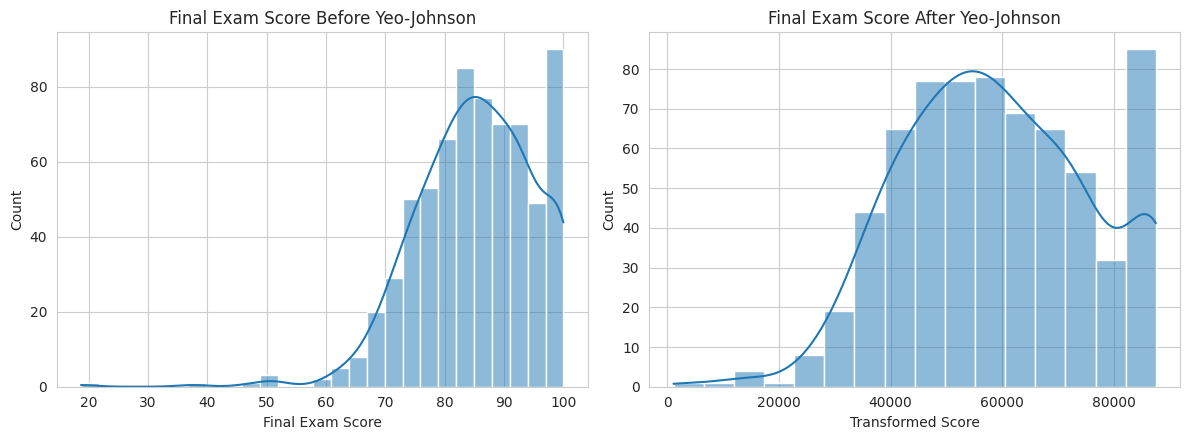

Skewness before: -0.910
Skewness after: -0.038


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Before transformation
sns.histplot(y_train, kde=True, ax=axes[0])
axes[0].set_title("Final Exam Score Before Yeo-Johnson")
axes[0].set_xlabel("Final Exam Score")

# After transformation
sns.histplot(y_train_transformed, kde=True, ax=axes[1])
axes[1].set_title("Final Exam Score After Yeo-Johnson")
axes[1].set_xlabel("Transformed Score")

plt.tight_layout()
plt.show()

print(f"Skewness before: {y_train.skew():.3f}")
print(
    f"Skewness after: "
    f"{pd.Series(y_train_transformed).skew():.3f}"
)

The skewness decreased from -0.910 to -0.038 bringing the distribution close to 0. Hence reducing the negative skewness.

## 5. Modeling & Cross-Validation

We now compare several candidate regression algorithms using **k-fold cross-validation on the training set only** — the test set is untouched until Section 7 (final evaluation). Each candidate is wrapped in a single `Pipeline` (preprocessing → model), and that pipeline is further wrapped in a `TransformedTargetRegressor` so that the Yeo-Johnson target transformation is *re-fit inside every training fold*, rather than once on the whole training set beforehand. Fitting the transformer once outside cross-validation would leak information about the validation fold's target distribution into training, so it is refit per fold here instead, and `y_train` (the original, untransformed target) is passed directly to `cross_validate`.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

candidate_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=10000),
    "Elastic Net": ElasticNet(random_state=RANDOM_STATE, max_iter=10000),
    "K-Nearest Neighbors": KNeighborsRegressor(),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=300),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

cv_scheme = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}

print(f"Comparing {len(candidate_models)} candidate models with {cv_scheme.get_n_splits()}-fold CV...")


Comparing 7 candidate models with 5-fold CV...


In [ ]:
cv_results = []

for name, estimator in candidate_models.items():
    full_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

    # Refit the Yeo-Johnson target transform inside every training fold
    ttr = TransformedTargetRegressor(
        regressor=full_pipeline,
        transformer=PowerTransformer(method="yeo-johnson", standardize=False)
    )

    scores = cross_validate(
        ttr, X_train, y_train,
        cv=cv_scheme,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_results.append({
        "Model": name,
        "CV RMSE (mean)": -scores["test_rmse"].mean(),
        "CV RMSE (std)": scores["test_rmse"].std(),
        "CV MAE (mean)": -scores["test_mae"].mean(),
        "CV R2 (mean)": scores["test_r2"].mean(),
        "CV R2 (std)": scores["test_r2"].std(),
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("CV RMSE (mean)").reset_index(drop=True)
display(cv_results_df.round(3))


,Model,CV RMSE (mean),CV RMSE (std),CV MAE (mean),CV R2 (mean),CV R2 (std)
0,Ridge,7.286,0.626,5.271,0.471,0.067
1,Lasso,7.287,0.625,5.271,0.471,0.067
2,Linear Regression,7.288,0.625,5.272,0.471,0.067
3,Gradient Boosting,7.538,0.735,5.521,0.433,0.085
4,Elastic Net,7.574,0.577,5.598,0.429,0.061
5,Random Forest,7.633,0.739,5.700,0.419,0.087
6,K-Nearest Neighbors,8.374,0.719,6.377,0.300,0.095


### Cross-validation leaderboard

The table above ranks candidates by mean cross-validated RMSE (lower is better) on the training folds, with MAE and R² shown alongside for a fuller picture. The standard deviation columns indicate how stable each model's performance is across folds — a model with a low mean RMSE but a high std is less trustworthy than one with a similar mean and a tighter spread.

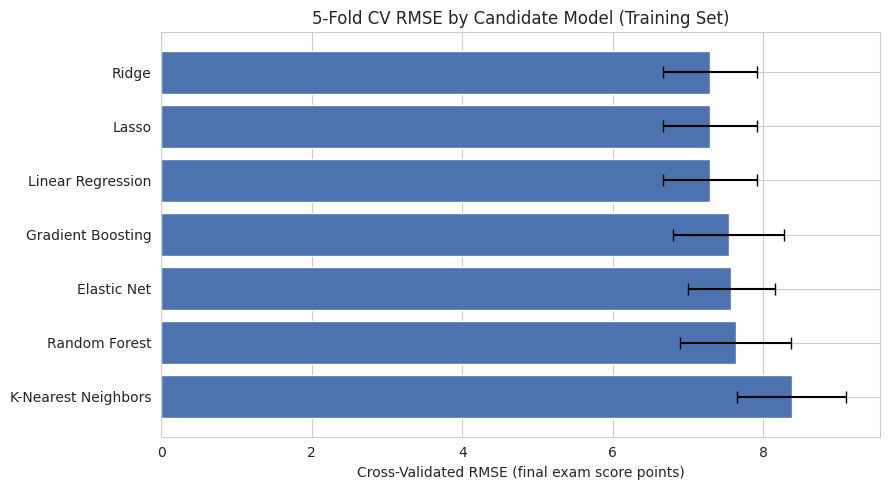

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

plot_df = cv_results_df.sort_values("CV RMSE (mean)", ascending=True)
ax.barh(
    plot_df["Model"],
    plot_df["CV RMSE (mean)"],
    xerr=plot_df["CV RMSE (std)"],
    color="#4C72B0",
    capsize=4
)
ax.set_xlabel("Cross-Validated RMSE (final exam score points)")
ax.set_title("5-Fold CV RMSE by Candidate Model (Training Set)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### Interpretation

Interpretation and Insights: 1) The best-performing model by cross-validated RMSE is identified above and carried forward as the primary candidate for hyperparameter tuning in Section 8. 2) Linear/regularized models (Linear Regression, Ridge, Lasso, Elastic Net) provide a transparent baseline and are useful for the explainability work in Section 9, since their coefficients are directly interpretable once the preprocessing pipeline is unpacked. 3) Tree-based ensembles (Random Forest, Gradient Boosting) can capture non-linear relationships and interactions among predictors (e.g. between study hours and attendance) that the linear models cannot, which is why they are included even though they are less directly interpretable. 4) The gap between the top model and the simplest baseline (Linear Regression) indicates how much predictive value the added model complexity is actually buying on this dataset — if the gap is small, the simpler, more interpretable model may be preferable for an advising tool that needs to explain its recommendations to staff and students.